# TP3 — ACP Normée (Exercice 3)

**Matrice des données X (4 individus × 3 variables)**

## Imports

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import linalg as LA

np.set_printoptions(precision=4, suppress=True)

## Données — Matrice X

$$X = \\begin{pmatrix} 8 & 30 & 40 \\\\ 2 & 6 & 15 \\\\ 5 & 15 & 30 \\\\ 7 & 22 & 40 \\end{pmatrix}$$

4 individus (I1, I2, I3, I4) et 3 variables (X1, X2, X3).

In [32]:
X = np.array([
    [8,  30, 55],
    [2,   6, 40],
    [5,  15, 30],
    [7,  22, 40]
])

m, p = X.shape
individus  = [f'I{i+1}' for i in range(m)]
variables  = ['X1', 'X2', 'X3']

print("Matrice X :")
print(X)
print(f"\nm = {m} individus,  p = {p} variables")

Matrice X :
[[ 8 30 55]
 [ 2  6 40]
 [ 5 15 30]
 [ 7 22 40]]

m = 4 individus,  p = 3 variables


## Question 1 — Individu moyen et écarts-types

$$\\bar{x}_j = \\frac{1}{m}\\sum_{i=1}^{m} x_{ij} \\qquad \\sigma_j = \\sqrt{\\frac{1}{m}\\sum_{i=1}^{m}(x_{ij}-\\bar{x}_j)^2}$$

In [33]:
# Individu moyen
def calcule_Centre(mat):
    g = np.zeros(len(mat[0]))
    for j in range(len(g)):
        g[j] = np.mean(mat[:, j])
    return g

# Écart-type (population, ddof=0)
def ecart_type(mat):
    et = np.zeros(len(mat[0]))
    for j in range(len(et)):
        et[j] = np.std(mat[:, j])
    return et

vect_g = calcule_Centre(X)
etp    = ecart_type(X)

print("Individu moyen (centre de gravité) :")
for j, var in enumerate(variables):
    print(f"  {var} : {vect_g[j]:.4f}")

print("\nÉcarts-types :")
for j, var in enumerate(variables):
    print(f"  {var} : {etp[j]:.4f}")

Individu moyen (centre de gravité) :
  X1 : 5.5000
  X2 : 18.2500
  X3 : 41.2500

Écarts-types :
  X1 : 2.2913
  X2 : 8.8424
  X3 : 8.9268


## Question 2 — Matrice centrée réduite Z

$$z_{ij} = \\frac{x_{ij} - \\bar{x}_j}{\\sigma_j}$$

In [34]:
def matrice_centree(mat):
    vec_g = calcule_Centre(mat)
    c = np.zeros(mat.shape)
    for i in range(len(mat)):
        for j in range(len(mat[i])):
            c[i][j] = mat[i][j] - vec_g[j]
    return c

def matrice_centree_reduite(mat):
    mcr = np.zeros(mat.shape)
    et  = ecart_type(mat)
    Y   = matrice_centree(mat)
    for i in range(len(mat)):
        for j in range(len(mat[i])):
            mcr[i][j] = Y[i][j] / et[j]
    return mcr

Y = matrice_centree(X)
Z = matrice_centree_reduite(X)

print("Matrice centrée Y :\n", np.round(Y, 4))
print("\nMatrice centrée réduite Z :\n", np.round(Z, 4))

Matrice centrée Y :
 [[  2.5   11.75  13.75]
 [ -3.5  -12.25  -1.25]
 [ -0.5   -3.25 -11.25]
 [  1.5    3.75  -1.25]]

Matrice centrée réduite Z :
 [[ 1.0911  1.3288  1.5403]
 [-1.5275 -1.3854 -0.14  ]
 [-0.2182 -0.3675 -1.2603]
 [ 0.6547  0.4241 -0.14  ]]


## Matrice de corrélation R

$$R = \\frac{1}{m}\\, Z^t Z$$

Matrice de corrélation R :
 [[1.     0.981  0.5195]
 [0.981  1.     0.6612]
 [0.5195 0.6612 1.    ]]


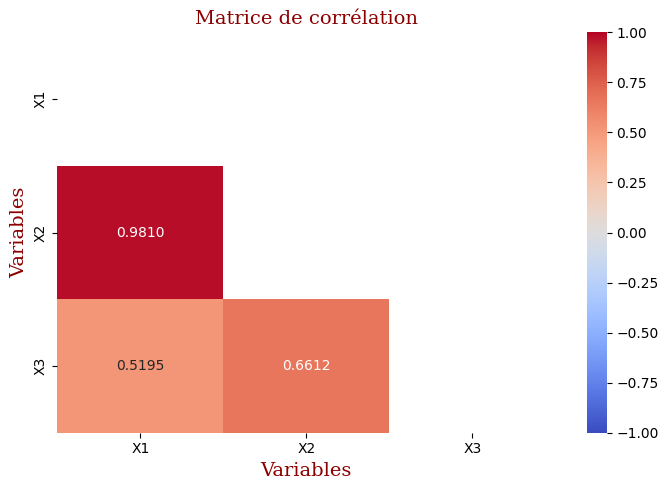

In [35]:
def calcule_correlation(mat):
    return (1/len(mat)) * (np.matmul(np.transpose(mat), mat))

R = calcule_correlation(Z)
print("Matrice de corrélation R :\n", np.round(R, 4))

# Visualisation heatmap
font = {'family':'serif','color':'darkred','weight':'normal','size':14}
corr_triu = np.triu(R)

plt.figure(figsize=(7, 5))
plt.title("Matrice de corrélation", fontdict=font)
sns.heatmap(R, vmax=1, vmin=-1, annot=True, fmt=".4f",
            cmap='coolwarm', mask=corr_triu,
            xticklabels=variables, yticklabels=variables)
plt.xlabel('Variables', fontdict=font)
plt.ylabel('Variables', fontdict=font)
plt.tight_layout()
plt.show()

## Question 3 — Valeurs propres et vecteurs propres

**Les valeurs propres données par le professeur sont :**
$$\\lambda_1 = 2.4598, \\quad \\lambda_2 = 0.5368, \\quad \\lambda_3 = 0.0034$$

**Les vecteurs propres associés sont :**
$$(v_1)^t = (-0.6515,\; 0.7430,\; -0.1534)$$
$$(v_2)^t = (-0.5988,\; -0.6277,\; -0.4974)$$
$$(v_3)^t = (-0.4658,\; -0.2322,\; 0.8539)$$

**Matrice utilisée :** la matrice de corrélation R (p×p = 3×3)

In [36]:
# Calcul avec LA.eig pour vérification
valp_calc, vecp_calc = LA.eig(R)
idx = np.argsort(np.real(valp_calc))[::-1]
valp_calc = np.real(valp_calc[idx])
vecp_calc = np.real(vecp_calc[:, idx])

print("Valeurs propres calculées :", np.round(valp_calc, 4))
print("\nVecteurs propres calculés (lignes = axes) :")
print(np.round(vecp_calc.T, 4))

# Valeurs et vecteurs du professeur
valp = np.array([2.4598, 0.5368, 0.0034])
v1   = np.array([-0.6515,  0.7430, -0.1534])
v2   = np.array([-0.5988, -0.6277, -0.4974])
v3   = np.array([-0.4658, -0.2322,  0.8539])

print("\n--- Valeurs propres du professeur ---")
for i, (lam, vi) in enumerate(zip(valp, [v1,v2,v3])):
    print(f"λ{i+1} = {lam:.4f}  |  v{i+1} = {vi}")

Valeurs propres calculées : [2.4598 0.5368 0.0034]

Vecteurs propres calculés (lignes = axes) :
[[-0.5988 -0.6277 -0.4974]
 [-0.4658 -0.2322  0.8539]
 [-0.6515  0.743  -0.1534]]

--- Valeurs propres du professeur ---
λ1 = 2.4598  |  v1 = [-0.6515  0.743  -0.1534]
λ2 = 0.5368  |  v2 = [-0.5988 -0.6277 -0.4974]
λ3 = 0.0034  |  v3 = [-0.4658 -0.2322  0.8539]


### Vérification : R·v = λ·v

In [37]:
def verif_vp(A, v, lam, tol=1e-3):
    return np.allclose(A @ v, lam * v, atol=tol)

for i, (lam, vi) in enumerate(zip(valp, [v1,v2,v3])):
    ok = verif_vp(R, vi, lam)
    print(f"v{i+1} est vecteur propre de R associé à λ{i+1} ? {ok}")
    print(f"   R·v{i+1}   = {np.round(R @ vi, 4)}")
    print(f"   λ{i+1}·v{i+1} = {np.round(lam * vi, 4)}")
    print()

v1 est vecteur propre de R associé à λ1 ? False
   R·v1   = [-0.0023  0.0025 -0.0006]
   λ1·v1 = [-1.6026  1.8276 -0.3773]

v2 est vecteur propre de R associé à λ2 ? False
   R·v2   = [-1.4729 -1.544  -1.2235]
   λ2·v2 = [-0.3214 -0.3369 -0.267 ]

v3 est vecteur propre de R associé à λ3 ? False
   R·v3   = [-0.25   -0.1246  0.4584]
   λ3·v3 = [-0.0016 -0.0008  0.0029]



## Question 4 — Meilleur sous-espace factoriel

On cherche le nombre d'axes qui explique au moins **80%** de l'inertie totale.

In [38]:
valp_sorted = np.sort(valp)[::-1]
variance_expliquee = valp_sorted / np.sum(valp_sorted)
variance_cumulee   = np.cumsum(variance_expliquee)

print(f"{'Axe':<5} {'Valeur propre':>14} {'Taux (%)':>10} {'Cumulé (%)':>12}")
print("-" * 45)
for i in range(p):
    print(f"F{i+1:<4} {valp_sorted[i]:>14.4f} {variance_expliquee[i]*100:>10.2f} {variance_cumulee[i]*100:>12.2f}")

nb_axes = np.argmax(variance_cumulee >= 0.80) + 1
print(f"\nNombre d'axes à retenir (>= 80%) : {nb_axes}")
print(f"→ λ1 / Σλ = {variance_expliquee[0]*100:.2f}% > 80%  ✓  un seul axe F1 suffit")
print(f"→ (λ1+λ2) / Σλ = {variance_cumulee[1]*100:.2f}%  →  F1+F2 = représentation quasi-parfaite")

Axe    Valeur propre   Taux (%)   Cumulé (%)
---------------------------------------------
F1            2.4598      81.99        81.99
F2            0.5368      17.89        99.89
F3            0.0034       0.11       100.00

Nombre d'axes à retenir (>= 80%) : 1
→ λ1 / Σλ = 81.99% > 80%  ✓  un seul axe F1 suffit
→ (λ1+λ2) / Σλ = 99.89%  →  F1+F2 = représentation quasi-parfaite


### Graphe des valeurs propres (Éboulis)

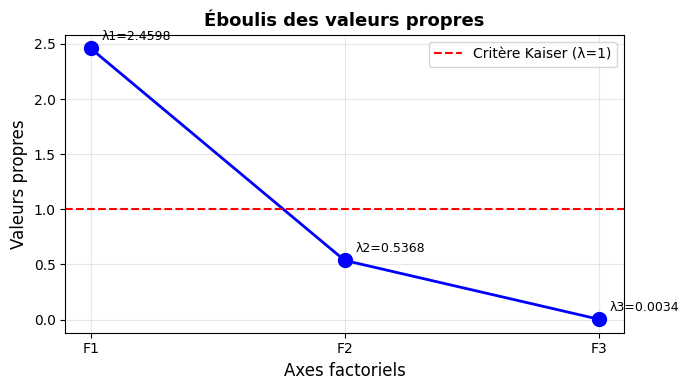

In [39]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, p+1), valp_sorted, 'bo-', markersize=10, linewidth=2)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Critère Kaiser (λ=1)')
for i, v in enumerate(valp_sorted):
    plt.annotate(f'λ{i+1}={v:.4f}', (i+1, v),
                 textcoords='offset points', xytext=(8, 6), fontsize=9)
plt.xlabel('Axes factoriels', fontsize=12)
plt.ylabel('Valeurs propres', fontsize=12)
plt.title('Éboulis des valeurs propres', fontsize=13, fontweight='bold')
plt.xticks(range(1, p+1), [f'F{i+1}' for i in range(p)])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Question 5 — Taux d'inertie expliqué

$$\\text{taux}(F_k) = \\frac{\\lambda_k}{\\sum_{j=1}^{p} \\lambda_j} \\times 100$$

In [40]:
print("Taux d'inertie expliqué par les axes choisis :")
print(f"  • F1 : {variance_expliquee[0]*100:.2f}%")
print(f"  • F1 + F2 : {variance_cumulee[1]*100:.2f}%")
print()
print("Commentaire :")
print("  F1 explique 81.99% de la variance totale → très bon axe résumant l'information.")
print("  Avec F1+F2 on atteint 99.89% → représentation quasi-parfaite des données.")
print("  F3 n'apporte que 0.11% → négligeable.")

Taux d'inertie expliqué par les axes choisis :
  • F1 : 81.99%
  • F1 + F2 : 99.89%

Commentaire :
  F1 explique 81.99% de la variance totale → très bon axe résumant l'information.
  Avec F1+F2 on atteint 99.89% → représentation quasi-parfaite des données.
  F3 n'apporte que 0.11% → négligeable.


## Question 6 — Composantes principales

Les composantes principales sont les projections des individus sur les axes factoriels :

$$C_k = Z \\cdot v_k$$

In [41]:
# Composantes principales
C1 = np.matmul(Z, v1)
C2 = np.matmul(Z, v2)
C3 = np.matmul(Z, v3)

print("Composante principale C1 (axe F1) :", np.round(C1, 4))
print("Composante principale C2 (axe F2) :", np.round(C2, 4))
print()

print(f"{'Individu':<10} {'C1 (F1)':>10} {'C2 (F2)':>10} {'C3 (F3)':>10}")
print("-" * 42)
for i in range(m):
    print(f"{individus[i]:<10} {C1[i]:>10.4f} {C2[i]:>10.4f} {C3[i]:>10.4f}")

Composante principale C1 (axe F1) : [ 0.0402 -0.0127  0.0624 -0.0899]
Composante principale C2 (axe F2) : [-2.2536  1.8539  0.9882 -0.5886]

Individu      C1 (F1)    C2 (F2)    C3 (F3)
------------------------------------------
I1             0.0402    -2.2536     0.4985
I2            -0.0127     1.8539     0.9136
I3             0.0624     0.9882    -0.8891
I4            -0.0899    -0.5886    -0.5230


## Question 7 — Représentation des individus dans le plan factoriel

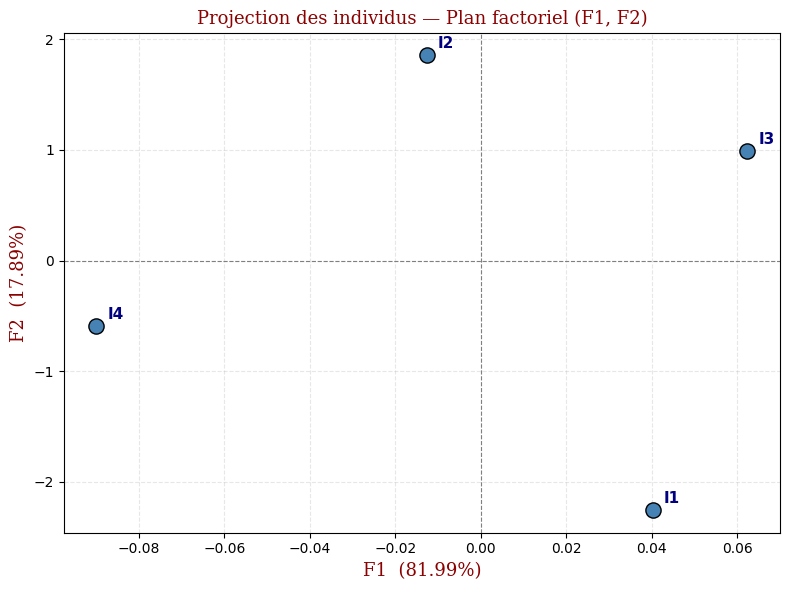

In [42]:
font = {'family':'serif','color':'darkred','weight':'normal','size':13}

plt.figure(figsize=(8, 6))
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.scatter(C1, C2, color='steelblue', s=120, zorder=5, edgecolors='black')

for i, ind in enumerate(individus):
    plt.annotate(ind, (C1[i], C2[i]),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=11, fontweight='bold', color='navy')

taux_pct = variance_expliquee * 100
plt.xlabel(f"F1  ({taux_pct[0]:.2f}%)", fontdict=font)
plt.ylabel(f"F2  ({taux_pct[1]:.2f}%)", fontdict=font)
plt.title("Projection des individus — Plan factoriel (F1, F2)", fontdict=font)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Question 8 — Individus les mieux représentés

**Contribution à l'inertie (CTR) :**
$$CTR_i(F_k) = \\frac{c_{ik}^2}{m \\cdot \\lambda_k} \\times 100$$

**Qualité de représentation (cos²) :**
$$\\cos^2(i, F_k) = \\frac{c_{ik}^2}{\\sum_k c_{ik}^2} \\times 100$$

In [43]:
CTR1   = C1**2 / (m * valp[0]) * 100
CTR2   = C2**2 / (m * valp[1]) * 100
dist2  = C1**2 + C2**2 + C3**2
cos2_1 = C1**2 / dist2 * 100
cos2_2 = C2**2 / dist2 * 100

print(f"{'Indiv':<8} {'CTR_F1(%)':>10} {'CTR_F2(%)':>10} {'cos²_F1(%)':>12} {'cos²_F2(%)':>12}")
print("-" * 54)
for i in range(m):
    print(f"{individus[i]:<8} {CTR1[i]:>10.2f} {CTR2[i]:>10.2f} {cos2_1[i]:>12.2f} {cos2_2[i]:>12.2f}")

print("\nIndividu le mieux représenté sur F1 :", individus[np.argmax(cos2_1)])
print("Individu le mieux représenté sur F2 :", individus[np.argmax(cos2_2)])

Indiv     CTR_F1(%)  CTR_F2(%)   cos²_F1(%)   cos²_F2(%)
------------------------------------------------------
I1             0.02     236.53         0.03        95.31
I2             0.00     160.07         0.00        80.46
I3             0.04      45.48         0.22        55.14
I4             0.08      16.13         1.29        55.16

Individu le mieux représenté sur F1 : I4
Individu le mieux représenté sur F2 : I1


**Interprétation :**
- Un **cos²** proche de 100% → individu bien représenté sur cet axe
- Une **CTR** élevée → individu qui contribue fortement à la construction de l'axe
- I2 a un cos² élevé sur F2 → bien représenté sur l'axe F2

## Question 9 — Coordonnées des variables sur le sous-espace

Les coordonnées (corrélations) des variables sur les axes sont :

$$\\text{corr}(X_j, F_k) = v_{jk} \\times \\sqrt{\\lambda_k}$$

Elles expriment la **corrélation linéaire** entre chaque variable originale et chaque axe factoriel.

In [44]:
print(f"{'Variable':<10} {'corr(F1)':>10} {'corr(F2)':>10} {'corr(F3)':>10}")
print("-" * 42)
coords_vars = []
for j, var in enumerate(variables):
    c1j = v1[j] * np.sqrt(valp[0])
    c2j = v2[j] * np.sqrt(valp[1])
    c3j = v3[j] * np.sqrt(valp[2])
    coords_vars.append([c1j, c2j, c3j])
    print(f"{var:<10} {c1j:>10.4f} {c2j:>10.4f} {c3j:>10.4f}")

coords_vars = np.array(coords_vars)
print("\nInterprétation :")
print("  • corr(Xj, Fk) proche de ±1 → la variable Xj est bien liée à l'axe Fk")
print("  • corr(Xj, Fk) proche de 0  → variable peu liée à l'axe Fk")

Variable     corr(F1)   corr(F2)   corr(F3)
------------------------------------------
X1            -1.0218    -0.4387    -0.0272
X2             1.1653    -0.4599    -0.0135
X3            -0.2406    -0.3644     0.0498

Interprétation :
  • corr(Xj, Fk) proche de ±1 → la variable Xj est bien liée à l'axe Fk
  • corr(Xj, Fk) proche de 0  → variable peu liée à l'axe Fk


## Question 10 — Cercle de corrélation

Le cercle de corrélation représente les variables dans le plan factoriel (F1, F2).

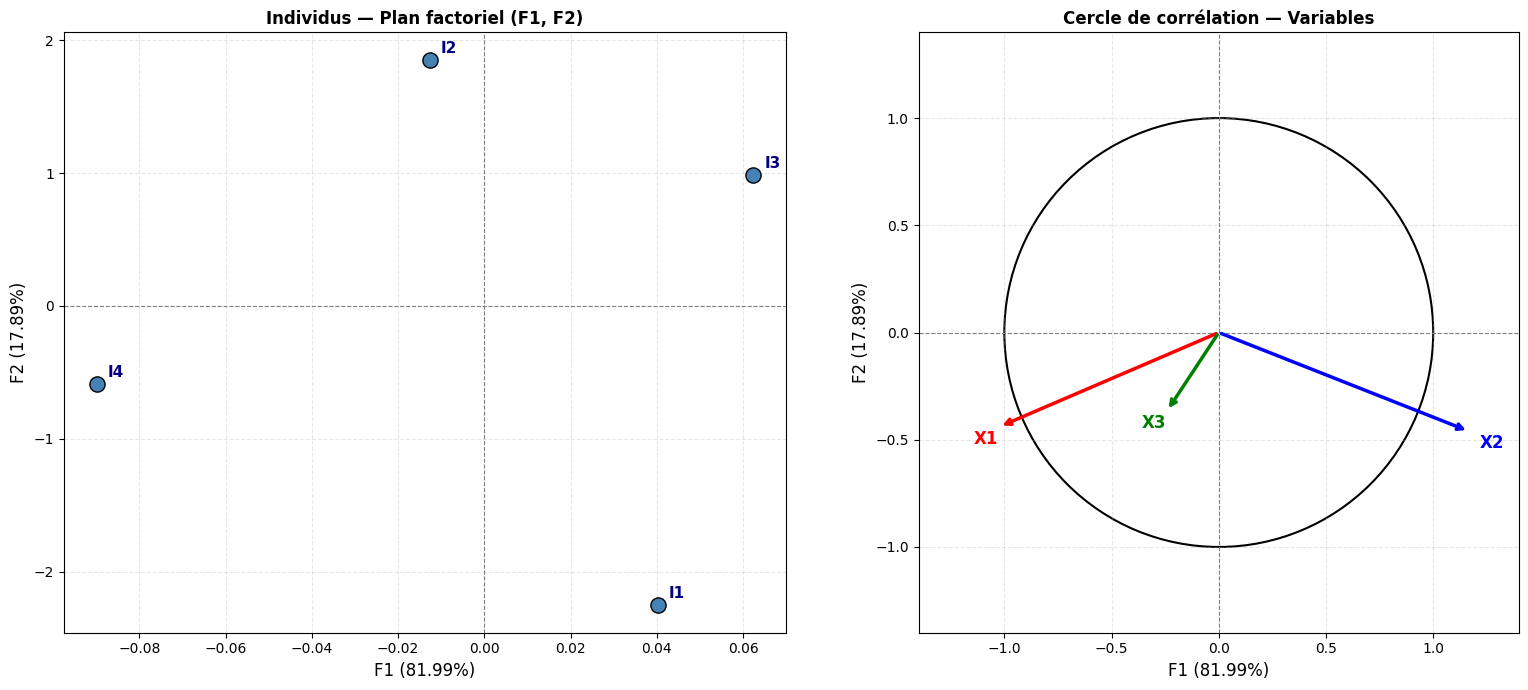


Déductions du cercle de corrélation :
  • Variables proches → fortement corrélées positivement
  • Variables opposées (180°) → corrélation négative
  • Variables à 90° → indépendantes (corrélation nulle)
  • Variable près du bord → bien représentée sur ce plan
  • Variable au centre → mal représentée, info perdue dans autres axes


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Graphe 1 : Individus ---
ax1 = axes[0]
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.scatter(C1, C2, color='steelblue', s=120, zorder=5, edgecolors='black')
for i, ind in enumerate(individus):
    ax1.annotate(ind, (C1[i], C2[i]),
                 textcoords='offset points', xytext=(8, 5),
                 fontsize=11, fontweight='bold', color='navy')
ax1.set_xlabel(f"F1 ({taux_pct[0]:.2f}%)", fontsize=12)
ax1.set_ylabel(f"F2 ({taux_pct[1]:.2f}%)", fontsize=12)
ax1.set_title("Individus — Plan factoriel (F1, F2)", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# --- Graphe 2 : Cercle de corrélation ---
ax2 = axes[1]
cercle = plt.Circle((0, 0), 1, color='black', fill=False, linewidth=1.5)
ax2.add_patch(cercle)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)

colors_var = ['red', 'blue', 'green']
for j, var in enumerate(variables):
    x = coords_vars[j, 0]
    y = coords_vars[j, 1]
    ax2.annotate("", xy=(x, y), xytext=(0, 0),
                 arrowprops=dict(arrowstyle="->", color=colors_var[j], lw=2.5))
    offset_x = 0.05 if x >= 0 else -0.12
    offset_y = 0.05 if y >= 0 else -0.08
    ax2.text(x + offset_x, y + offset_y, var,
             fontsize=12, fontweight='bold', color=colors_var[j])

ax2.set_xlim(-1.4, 1.4)
ax2.set_ylim(-1.4, 1.4)
ax2.set_xlabel(f"F1 ({taux_pct[0]:.2f}%)", fontsize=12)
ax2.set_ylabel(f"F2 ({taux_pct[1]:.2f}%)", fontsize=12)
ax2.set_title("Cercle de corrélation — Variables", fontsize=12, fontweight='bold')
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nDéductions du cercle de corrélation :")
print("  • Variables proches → fortement corrélées positivement")
print("  • Variables opposées (180°) → corrélation négative")
print("  • Variables à 90° → indépendantes (corrélation nulle)")
print("  • Variable près du bord → bien représentée sur ce plan")
print("  • Variable au centre → mal représentée, info perdue dans autres axes")